# CLIQUE (CLustering In QUEst) Subspace Clustering

- CLIQUE: grid-based subspace clustering — finds clusters that exist in subsets of features (subspaces), not necessarily all features at once
- Key insight: in high-dimensional data, clusters often only appear in certain feature combinations, not the full space
- No sklearn implementation — built from scratch using NumPy
- Dataset: iris.csv (4 features — clusters visible in different feature pairs/subspaces)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/iris[1].csv")

# Drop species column — unsupervised, no labels used during clustering
# Keep it aside to evaluate results afterward
species = df["species"] if "species" in df.columns else df["variety"]
X = df.drop(columns=[col for col in ["species", "variety", "Id"] if col in df.columns]).values
feature_names = [col for col in df.columns if col not in ["species", "variety", "Id"]]

print("Shape:", X.shape)
print("Features:", feature_names)
print(df.head())


Shape: (150, 4)
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [5]:
# CLIQUE Implementation from scratch

class CLIQUE:
    def __init__(self, xi=5, tau=0.1):
        # xi: number of equal-width intervals (bins) per dimension
        # tau: density threshold — fraction of total points a cell must contain to be "dense"
        self.xi = xi
        self.tau = tau

    def fit_predict(self, X):
        n_samples, n_features = X.shape
        min_points = max(1, int(self.tau * n_samples))

        # Step 1: compute bin edges for each dimension
        bins = []
        for d in range(n_features):
            col = X[:, d]
            b = np.linspace(col.min() - 1e-6, col.max() + 1e-6, self.xi + 1)
            bins.append(b)

        # Step 2: get bin assignment for every point in every dimension
        bin_assignments = np.zeros((n_samples, n_features), dtype=int)
        for d in range(n_features):
            for i in range(n_samples):
                b = np.searchsorted(bins[d], X[i, d], side="right") - 1
                bin_assignments[i, d] = min(max(b, 0), self.xi - 1)

        # Step 3: for each pair of dimensions (subspace), find dense 2D cells
        labels = np.full(n_samples, -1)
        cluster_id = 0

        for d1, d2 in combinations(range(n_features), 2):
            # count points per 2D cell in this subspace
            cell_counts = {}
            for i in range(n_samples):
                cell = (bin_assignments[i, d1], bin_assignments[i, d2])
                cell_counts[cell] = cell_counts.get(cell, 0) + 1

            # mark dense cells
            dense_cells = {cell for cell, cnt in cell_counts.items() if cnt >= min_points}
            if not dense_cells:
                continue

            # BFS: connect adjacent dense cells into clusters
            visited = set()
            for start in dense_cells:
                if start in visited:
                    continue
                cluster_cells = set()
                queue = [start]
                visited.add(start)
                while queue:
                    cell = queue.pop(0)
                    cluster_cells.add(cell)
                    for da, db in [(-1,0),(1,0),(0,-1),(0,1)]:
                        neighbor = (cell[0]+da, cell[1]+db)
                        if neighbor in dense_cells and neighbor not in visited:
                            visited.add(neighbor)
                            queue.append(neighbor)

                # assign points in this cluster
                for i in range(n_samples):
                    cell = (bin_assignments[i, d1], bin_assignments[i, d2])
                    if cell in cluster_cells and labels[i] == -1:
                        labels[i] = cluster_id
                cluster_id += 1

        self.bins_ = bins
        self.bin_assignments_ = bin_assignments
        return labels


In [6]:
model = CLIQUE(xi=5, tau=0.08)
labels = model.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters found:", n_clusters)
print("Noise points  :", list(labels).count(-1))

Clusters found: 8
Noise points  : 7


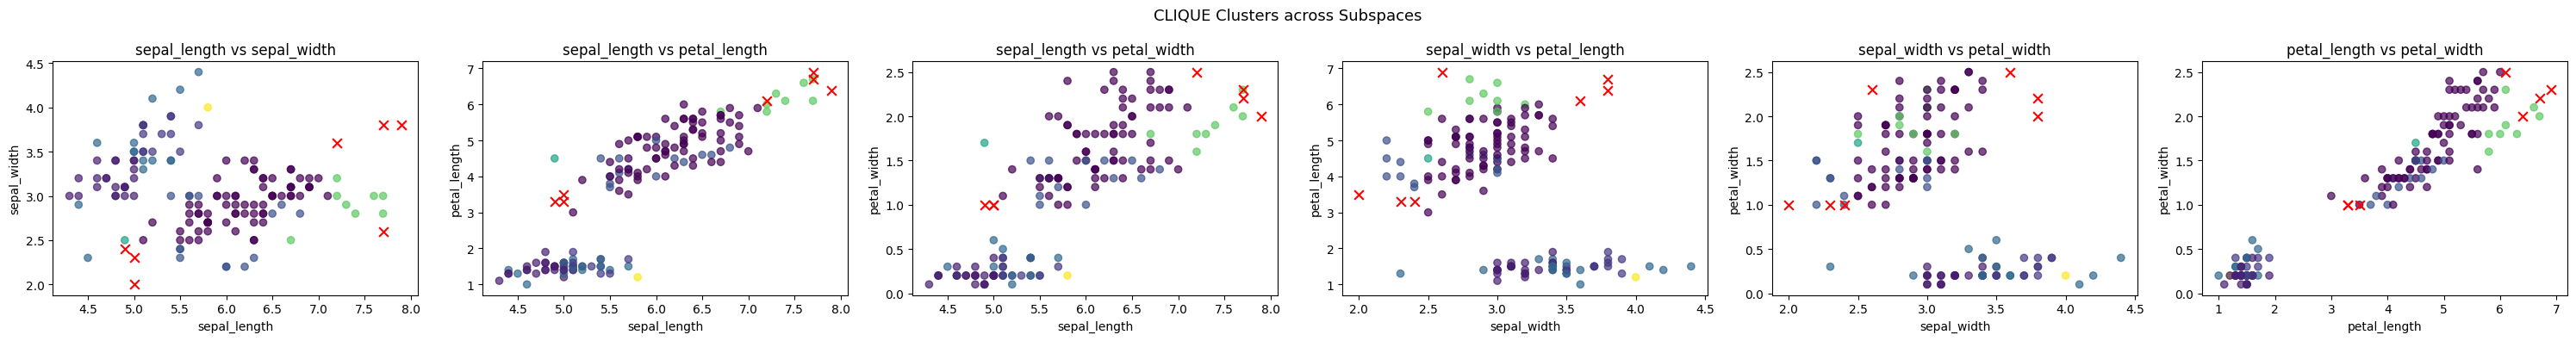

In [7]:
# Visualize clusters across all feature pairs (subspaces)
pairs = list(combinations(range(len(feature_names)), 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))

for ax, (d1, d2) in zip(axes, pairs):
    mask_noise = labels == -1
    ax.scatter(X[~mask_noise, d1], X[~mask_noise, d2],
               c=labels[~mask_noise], cmap="viridis", alpha=0.7)
    ax.scatter(X[mask_noise, d1], X[mask_noise, d2],
               c="red", marker="x", s=60, label="Noise")
    ax.set_xlabel(feature_names[d1])
    ax.set_ylabel(feature_names[d2])
    ax.set_title(f"{feature_names[d1]} vs {feature_names[d2]}")

plt.suptitle("CLIQUE Clusters across Subspaces", fontsize=13)
plt.tight_layout()
plt.show()
# Different subspace plots may show clusters more or less clearly
# This is the key CLIQUE insight — some clusters only appear in specific feature pairs

In [8]:
# Compare CLIQUE clusters against actual species labels
df["Cluster"] = labels
df["Species"] = species.values

print("Cluster vs Species distribution:")
print(df.groupby(["Cluster", "Species"]).size().unstack(fill_value=0))

Cluster vs Species distribution:
Species  setosa  versicolor  virginica
Cluster                               
-1            0           3          4
 0            0          34         36
 1           22           0          0
 2           13           0          0
 3            0          13          1
 4           14           0          0
 7            0           0          1
 9            0           0          8
 12           1           0          0


## Conclusion
- CLIQUE divided each feature dimension into xi equal-width bins, then found 2D cells (subspaces) with density ≥ tau
- Adjacent dense cells in each subspace were merged via BFS into clusters
- Points in sparse cells across all subspaces were labeled as noise (-1)
- The subspace plots show how clusters may appear clearly in some feature pairs but not others — this is CLIQUE's core contribution over K-Means/DBSCAN (which cluster in the full feature space only)
- Key parameters to tune: xi (bin resolution) and tau (density threshold) — higher xi gives finer grid, lower tau accepts sparser cells as dense
- Key limitation: the number of subspaces grows quadratically with features — CLIQUE uses the Apriori principle (if a subspace is not dense, no higher-dimensional subspace containing it can be dense) to prune this search

Save as CLIQUE.ipynb
Upload to 03_Machine_Learning/06_Unsupervised_Learning/
